In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Load dataset
df = pd.read_csv("new.csv")

# Step 2: Handle missing values
df['Income'] = df['Income'].fillna(df['Income'].median())

# Step 3: Define features (X) and target (y)
numeric_cols = ['Income','MntWines','MntFruits','MntMeatProducts',
                'MntFishProducts','MntSweetProducts','MntGoldProds',
                'NumDealsPurchases','NumWebPurchases','NumCatalogPurchases',
                'NumStorePurchases','NumWebVisitsMonth']

X = df[numeric_cols]
y = df['Response']   # Target column

# Step 4: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 6: Build Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Step 7: Predictions
y_pred = rf.predict(X_test)

# Step 8: Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Step 9: Feature Importance
importances = rf.feature_importances_
feature_importance = pd.DataFrame({'Feature': numeric_cols, 'Importance': importances})
print(feature_importance.sort_values(by='Importance', ascending=False))


Accuracy: 0.859375

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92       379
           1       0.62      0.23      0.34        69

    accuracy                           0.86       448
   macro avg       0.74      0.60      0.63       448
weighted avg       0.83      0.86      0.83       448

                Feature  Importance
1              MntWines    0.138281
0                Income    0.129481
3       MntMeatProducts    0.123057
6          MntGoldProds    0.097075
5      MntSweetProducts    0.076588
4       MntFishProducts    0.074307
2             MntFruits    0.073686
9   NumCatalogPurchases    0.064679
10    NumStorePurchases    0.063350
11    NumWebVisitsMonth    0.062835
8       NumWebPurchases    0.054126
7     NumDealsPurchases    0.042535


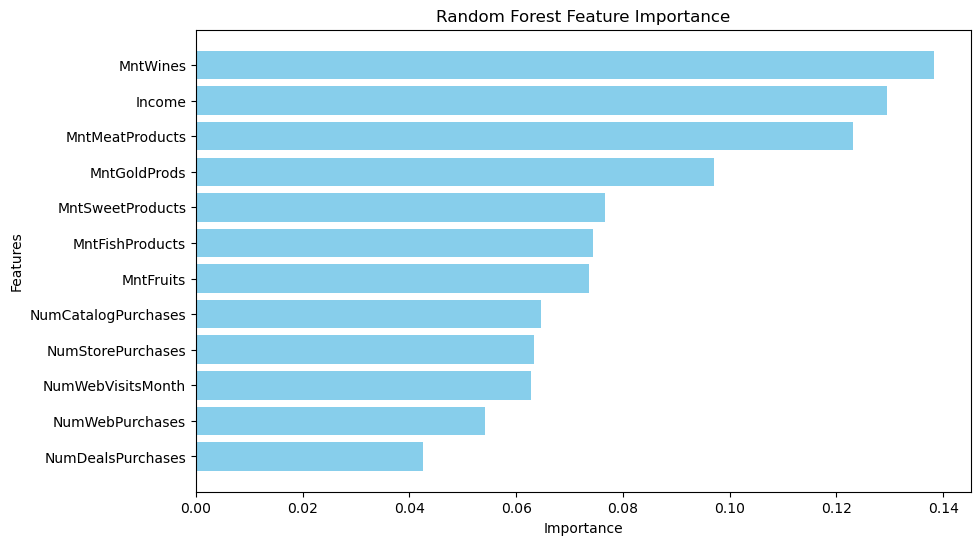

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv("new.csv")

# Handle missing values
df['Income'] = df['Income'].fillna(df['Income'].median())

# Features and target
numeric_cols = ['Income','MntWines','MntFruits','MntMeatProducts',
                'MntFishProducts','MntSweetProducts','MntGoldProds',
                'NumDealsPurchases','NumWebPurchases','NumCatalogPurchases',
                'NumStorePurchases','NumWebVisitsMonth']

X = df[numeric_cols]
y = df['Response']

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature importance
importances = rf.feature_importances_
feature_importance = pd.DataFrame({'Feature': numeric_cols, 'Importance': importances})
feature_importance = feature_importance.sort_values(by='Importance', ascending=True)

# Horizontal bar plot
plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='skyblue')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()
